In [10]:
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
df_trend = pd.read_csv("data/sony_digital_vs_physical.csv")
df_trend

,fiscal_year,period,digital_ratio_pct,physical_ratio_pct,source
0,FY2015,Full Year,19,81,PushSquare/ResetEra (Sony historical data)
1,FY2020,Full Year,65,35,PushSquare/ResetEra (pandemic boost)
2,FY2023,Full Year,70,30,PushSquare/ResetEra
3,FY2024,Full Year,76,24,Notebookcheck (Sony FY2024 Q4 Supplemental Rep...
4,FY2024,Q4,80,20,GameSpot
5,FY2025,Full Year,78,22,Niche Gamer / PushSquare (Sony FY2025 Q4 Finan...
6,FY2025,Q4,85,15,Niche Gamer / GameSpot (Sony FY2025 Q4 Financi...


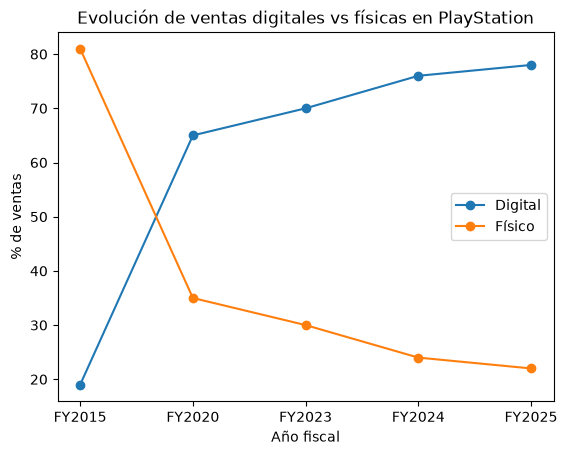

In [12]:
df_full_year = df_trend[df_trend["period"] == "Full Year"]

plt.plot(df_full_year["fiscal_year"], df_full_year["digital_ratio_pct"], marker="o", label="Digital")
plt.plot(df_full_year["fiscal_year"], df_full_year["physical_ratio_pct"], marker="o", label="Físico")
plt.title("Evolución de ventas digitales vs físicas en PlayStation")
plt.xlabel("Año fiscal")
plt.ylabel("% de ventas")
plt.legend()
plt.show()

In [13]:
df_revenue = pd.read_csv("data/sony_revenue_by_format.csv")
df_revenue

,fiscal_period,format,revenue_usd_millions,source
0,FY2025 Q4,Digital software,1500,Niche Gamer (Sony FY2025 Q4 Financial Results)
1,FY2025 Q4,Physical software,109,Niche Gamer (Sony FY2025 Q4 Financial Results)


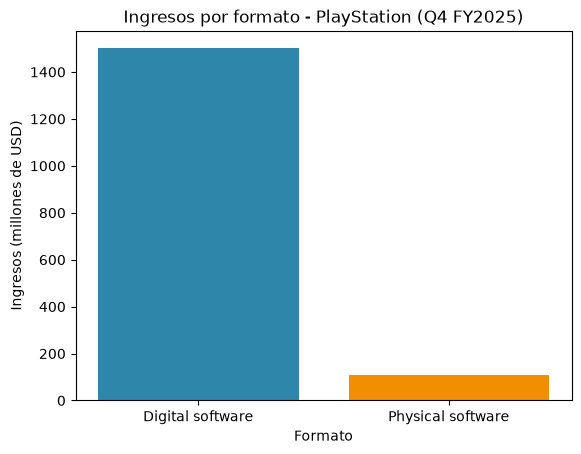

In [14]:
plt.bar(df_revenue["format"], df_revenue["revenue_usd_millions"], color=["#2E86AB", "#F18F01"])
plt.title("Ingresos por formato - PlayStation (Q4 FY2025)")
plt.xlabel("Formato")
plt.ylabel("Ingresos (millones de USD)")
plt.show()

In [15]:
df_composicion = pd.read_csv("data/sony_gns_revenue_composition_fy2024.csv")
df_composicion

,revenue_category,share_pct,source
0,"Add-on content (DLC, season passes, microtrans...",29,Notebookcheck (Sony FY2024 Supplemental Inform...
1,Hardware,24,Notebookcheck (Sony FY2024 Supplemental Inform...
2,Digital software,20,Notebookcheck (Sony FY2024 Supplemental Inform...
3,"Network services (PS Plus, ads)",14,Notebookcheck (Sony FY2024 Supplemental Inform...
4,Physical software,3,Notebookcheck (Sony FY2024 Supplemental Inform...


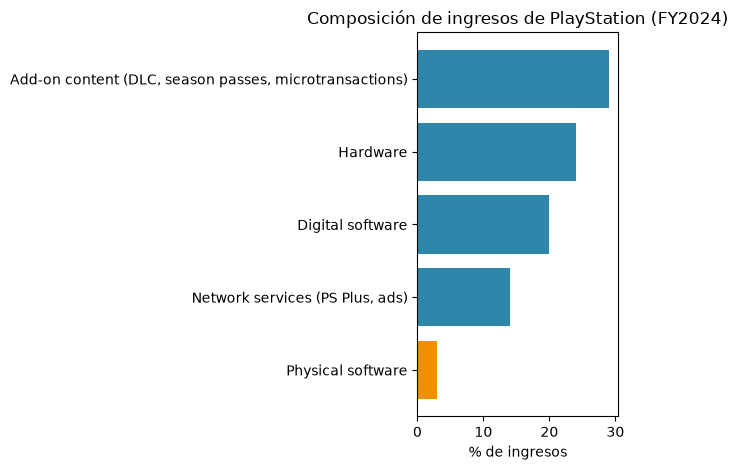

In [16]:
df_composicion_ordenado = df_composicion.sort_values("share_pct")
colores = ["#F18F01" if cat == "Physical software" else "#2E86AB" for cat in df_composicion_ordenado["revenue_category"]]

plt.barh(df_composicion_ordenado["revenue_category"], df_composicion_ordenado["share_pct"], color=colores)
plt.title("Composición de ingresos de PlayStation (FY2024)")
plt.xlabel("% de ingresos")
plt.tight_layout()
plt.show()

In [17]:
categorias_digitales = ["Add-on content (DLC, season passes, microtransactions)", "Digital software", "Network services (PS Plus, ads)"]
df_digital_breakdown = df_composicion[df_composicion["revenue_category"].isin(categorias_digitales)]
df_digital_breakdown

,revenue_category,share_pct,source
0,"Add-on content (DLC, season passes, microtrans...",29,Notebookcheck (Sony FY2024 Supplemental Inform...
2,Digital software,20,Notebookcheck (Sony FY2024 Supplemental Inform...
3,"Network services (PS Plus, ads)",14,Notebookcheck (Sony FY2024 Supplemental Inform...


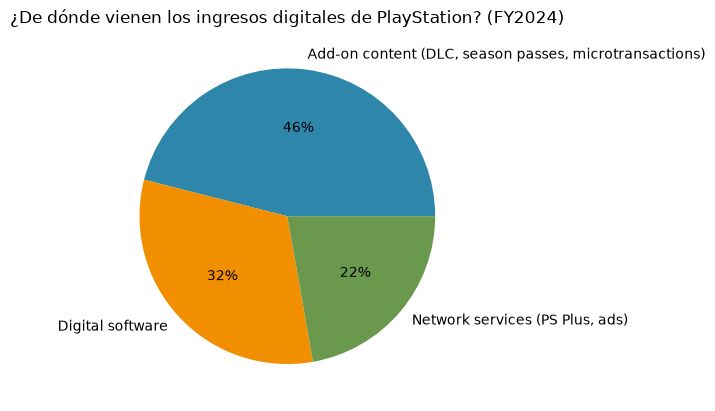

In [18]:
plt.pie(df_digital_breakdown["share_pct"], labels=df_digital_breakdown["revenue_category"], autopct="%1.0f%%", colors=["#2E86AB", "#F18F01", "#6A994E"])
plt.title("¿De dónde vienen los ingresos digitales de PlayStation? (FY2024)")
plt.show()

In [21]:
df_exclusivos = pd.read_csv("data/sony_exclusivos_fisico.csv")
df_exclusivos

,exclusive_title,physical_share_pct,source
0,Uncharted 4,83,Insomniac Games internal leak 2023 (widely rep...
1,God of War Ragnarok,76,Insomniac Games internal leak 2023 (widely rep...
2,Ratchet and Clank Rift Apart,75,Insomniac Games internal leak 2023 (widely rep...
3,The Last of Us Part 2,60,Insomniac Games internal leak 2023 (widely rep...
4,Spider-Man 2,54,Insomniac Games internal leak 2023 (widely rep...


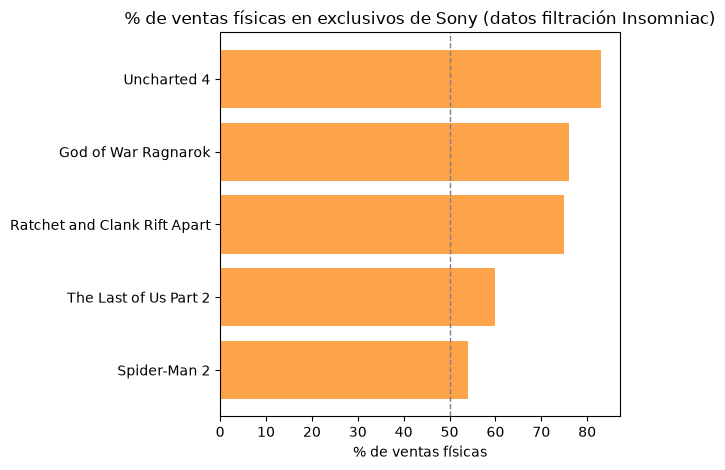

In [27]:
df_exclusivos_ordenado = df_exclusivos.sort_values("physical_share_pct")

plt.barh(df_exclusivos_ordenado["exclusive_title"], df_exclusivos_ordenado["physical_share_pct"], color="#FDA44B")
plt.title("% de ventas físicas en exclusivos de Sony (datos filtración Insomniac)")
plt.xlabel("% de ventas físicas")
plt.axvline(x=50, color="gray", linestyle="--", linewidth=1)
plt.tight_layout()
plt.show()

## Conclusión

Los datos financieros generales de Sony muestran una tendencia clara e innegable hacia lo digital:
el 78% de las ventas de software en FY2025 ya son digitales, y el software físico representa
apenas el 3% de los ingresos totales del segmento Game & Network Services.

Sin embargo, eliminar por completo el formato físico para 2028 **aún no parece del todo viable**,
al menos no de forma generalizada. La filtración de datos internos de Insomniac Games muestra que
varios de los exclusivos más importantes de Sony —Uncharted 4 (83%), God of War Ragnarök (76%),
Ratchet & Clank: Rift Apart (75%), The Last of Us Part 2 (60%) y Spider-Man 2 (54%)— vendieron la
mayoría de sus copias en formato físico. 

Esto sugiere que una eliminación completa del físico podría perjudicar desproporcionadamente a este
tipo de títulos, mientras que tiene mucho más sentido en catálogos digitales, DLC, juegos como
servicio y contenido antiguo, donde el consumidor ya ha migrado casi por completo a lo digital.

**En resumen:** los números respaldan la dirección general de la decisión de Sony, pero no
necesariamente su alcance total — mantener el físico limitado a los lanzamientos triple A más
importantes podría ser un punto intermedio más alineado con el comportamiento real del consumidor.